# Generative AI Experiment: Variational Autoencoder on MNIST

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Course:** AI Mastery — Module 5: Generative AI Applications
**Date:** April 2026

---

This notebook implements a **Variational Autoencoder (VAE)** trained on the **MNIST handwritten digit dataset**.
The goal is to learn a compact latent representation of handwritten digits and use it to generate new samples.

**Sections:**
1. Setup
2. Dataset & Preprocessing
3. VAE Architecture
4. Training
5. Output Evaluation
6. Notebook Summary

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Hyperparameters
BATCH_SIZE = 128
EPOCHS     = 20
LR         = 1e-3
LATENT_DIM = 20

sns.set_theme(style='whitegrid')

print(f'PyTorch:     {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print(f'NumPy:       {np.__version__}')
print(f'matplotlib:  {matplotlib.__version__}')
print(f'Device:      {DEVICE}')
print(f'Latent dim:  {LATENT_DIM}')
print(f'Epochs:      {EPOCHS}')

PyTorch:     2.11.0
torchvision: 0.26.0
NumPy:       2.4.4
matplotlib:  3.10.8
Device:      cpu
Latent dim:  20
Epochs:      20


## 2. Dataset & Preprocessing

**MNIST** (LeCun et al., 1998) contains 70,000 grayscale 28×28 images of handwritten digits (0–9):
60,000 training and 10,000 test images, perfectly balanced across 10 classes.

Images are downloaded automatically via `torchvision.datasets.MNIST` on first run.
Pixel values are normalised to [0, 1] using `transforms.ToTensor()` — appropriate for the Sigmoid output of the VAE decoder,
which also produces values in [0, 1]. Binary Cross-Entropy loss operates on this same range.

In [2]:
transform = transforms.ToTensor()  # normalises [0,255] -> [0,1]

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training images : {len(train_dataset):,}')
print(f'Test images     : {len(test_dataset):,}')
print(f'Image shape     : {train_dataset[0][0].shape}')
print(f'Classes         : {train_dataset.classes}')

100.0%
100.0%
100.0%
100.0%

Training images : 60,000
Test images     : 10,000
Image shape     : torch.Size([1, 28, 28])
Classes         : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


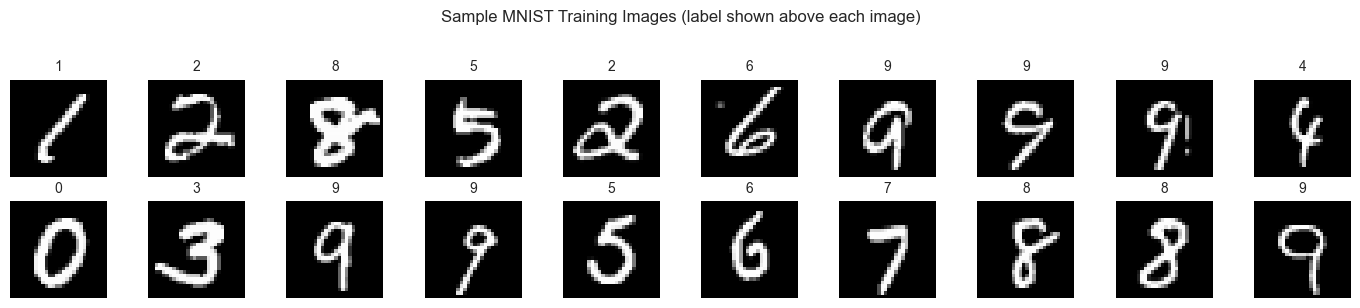

Pixel value range: [0.000, 1.000]


In [3]:
# Display 10 sample images from the training set
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(str(labels[i].item()), fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(images[10 + i].squeeze(), cmap='gray')
    axes[1, i].set_title(str(labels[10 + i].item()), fontsize=10)
    axes[1, i].axis('off')

fig.suptitle('Sample MNIST Training Images (label shown above each image)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('Pixel value range: [{:.3f}, {:.3f}]'.format(images.min().item(), images.max().item()))